# 🧹 Data Preparation — Employee Attrition Risk Prediction
**Dikerjakan oleh:** Zahra Daniah

**Tanggung jawab:**
- ✅ Data Cleaning
- ✅ Data Preprocessing
- ✅ Feature Engineering

**Dataset:** [IBM HR Analytics Employee Attrition & Performance](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)

---

## 📦 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

print('✅ Library berhasil diimport')

✅ Library berhasil diimport


## 📂 2. Load Dataset

In [2]:
# Load dataset IBM HR Analytics
df = pd.read_csv('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')

print(f'📊 Shape dataset: {df.shape}')
print(f'📋 Jumlah baris: {df.shape[0]}')
print(f'📋 Jumlah kolom: {df.shape[1]}')
df.head()

📊 Shape dataset: (1470, 35)
📋 Jumlah baris: 1470
📋 Jumlah kolom: 35


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
# Simpan salinan awal sebelum preprocessing
df_original = df.copy()

# Informasi umum dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [4]:
# Statistik deskriptif
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0


---
## 🧹 3. DATA CLEANING

### 3.1 Cek & Tangani Missing Values

In [5]:
# Hitung missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct.round(2)
}).sort_values('Missing (%)', ascending=False)

print('=== MISSING VALUES ===')
print(missing_df[missing_df['Missing Count'] > 0])

if missing_df['Missing Count'].sum() == 0:
    print('✅ Tidak ada missing values!')

=== MISSING VALUES ===
Empty DataFrame
Columns: [Missing Count, Missing (%)]
Index: []
✅ Tidak ada missing values!


In [6]:
# Visualisasi missing values
plt.figure(figsize=(12, 5))
missing_plot = missing_pct[missing_pct > 0]

if len(missing_plot) > 0:
    missing_plot.plot(kind='bar', color='salmon')
    plt.title('Persentase Missing Values per Kolom')
    plt.ylabel('Persentase (%)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('✅ Tidak ada missing values untuk divisualisasikan.')

✅ Tidak ada missing values untuk divisualisasikan.


<Figure size 1200x500 with 0 Axes>

In [7]:
# Penanganan missing values (jika ada)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f'✅ {col}: missing diisi dengan median ({df[col].median():.2f})')

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)
        print(f'✅ {col}: missing diisi dengan modus ({df[col].mode()[0]})')

print(f'\n✅ Total missing setelah penanganan: {df.isnull().sum().sum()}')


✅ Total missing setelah penanganan: 0


### 3.2 Cek & Hapus Duplikat

In [8]:
dup_count = df.duplicated().sum()
print(f'🔍 Jumlah baris duplikat: {dup_count}')

if dup_count > 0:
    df.drop_duplicates(inplace=True)
    print(f'✅ Duplikat dihapus. Shape sekarang: {df.shape}')
else:
    print('✅ Tidak ada data duplikat!')

🔍 Jumlah baris duplikat: 0
✅ Tidak ada data duplikat!


### 3.3 Hapus Kolom Tidak Relevan

Dataset IBM HR memiliki beberapa kolom yang tidak informatif untuk modeling:
- **EmployeeNumber**: ID unik karyawan
- **EmployeeCount**: semua bernilai 1
- **Over18**: semua bernilai 'Y'
- **StandardHours**: semua bernilai 80

In [9]:
# Cek kolom dengan nilai unik tunggal
single_val_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f'Kolom dengan 1 nilai unik: {single_val_cols}')

# Kolom yang dihapus
cols_to_drop = ['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours']
cols_to_drop = [col for col in cols_to_drop if col in df.columns]

df.drop(columns=cols_to_drop, inplace=True)
print(f'✅ Kolom dihapus: {cols_to_drop}')
print(f'📊 Shape sekarang: {df.shape}')

Kolom dengan 1 nilai unik: ['EmployeeCount', 'Over18', 'StandardHours']
✅ Kolom dihapus: ['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours']
📊 Shape sekarang: (1470, 31)


### 3.4 Cek & Tangani Outlier

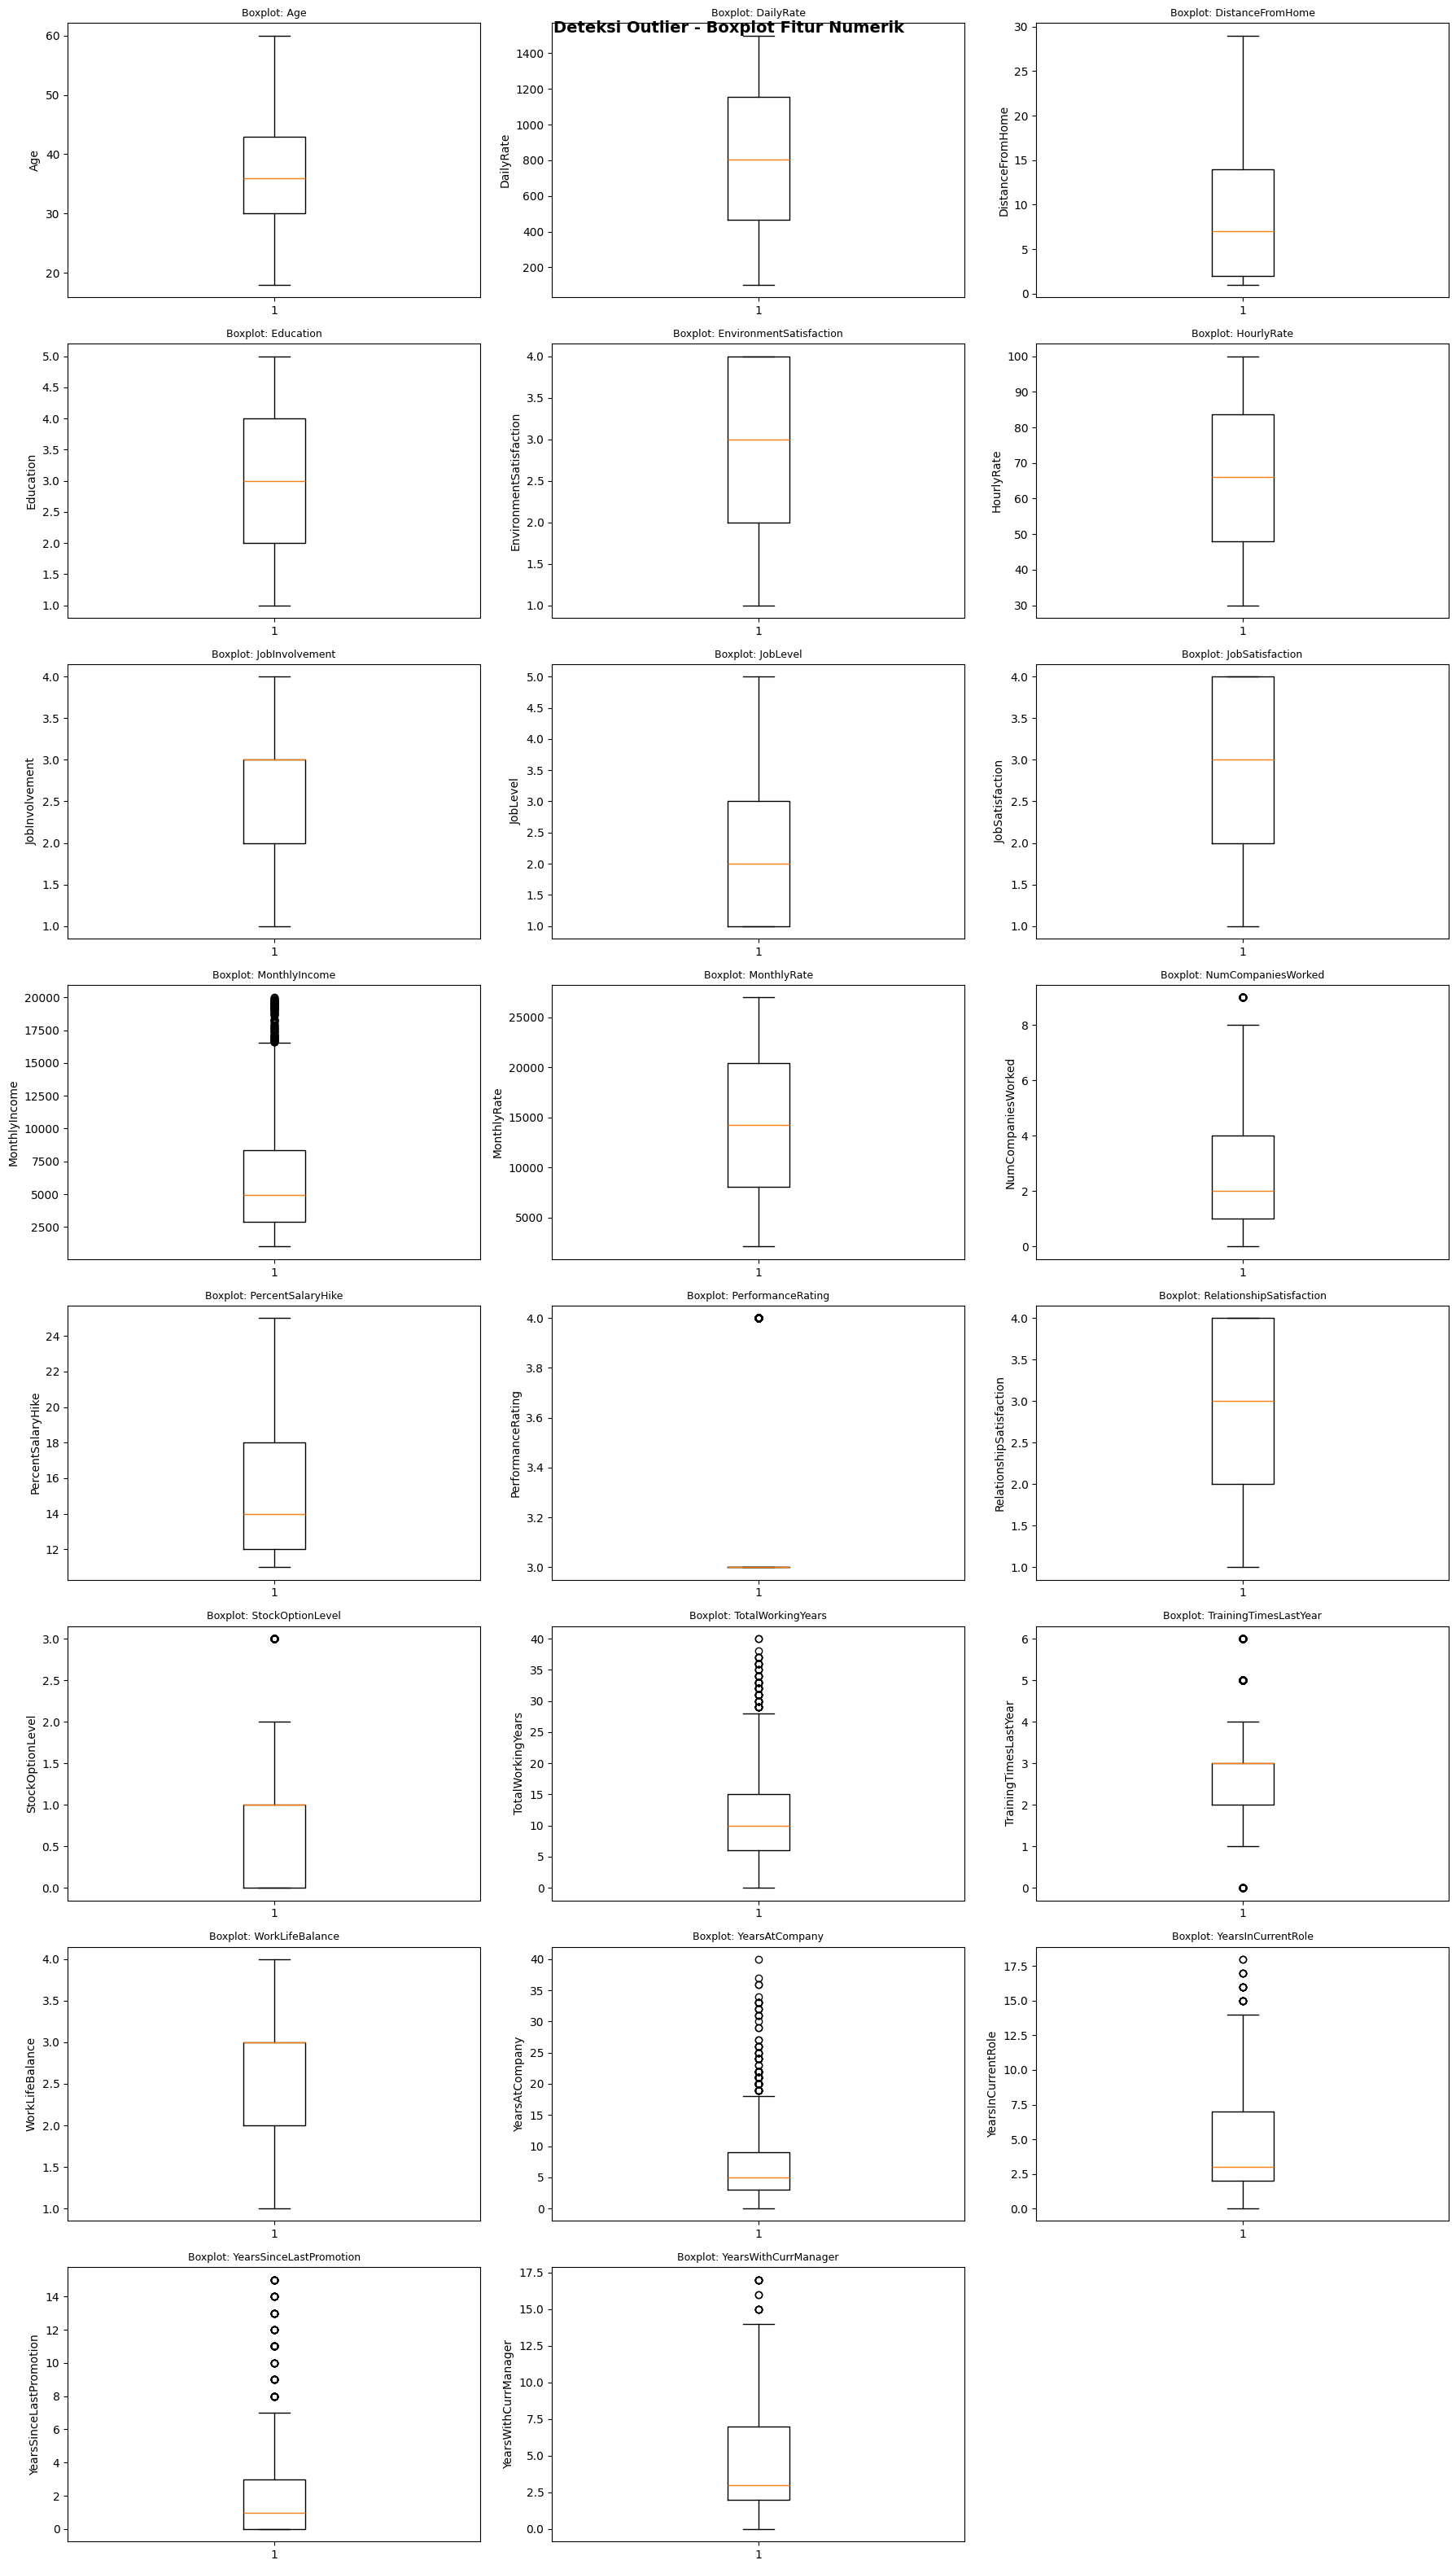

In [10]:
# Visualisasi outlier dengan boxplot
num_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_features_plot = [col for col in num_features if col != 'Attrition']

n_cols = 3
n_rows = (len(num_features_plot) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_features_plot):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(f'Boxplot: {col}', fontsize=9)
    axes[i].set_ylabel(col)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Deteksi Outlier - Boxplot Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# Tangani outlier dengan IQR Capping
def cap_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    if n_outliers > 0:
        df[col] = df[col].clip(lower=lower, upper=upper)
        print(f'  ⚠️  {col}: {n_outliers} outlier di-cap (lower={lower:.2f}, upper={upper:.2f})')
    return df

# Skip kolom rating/skala bounded
bounded_cols = ['Education', 'EnvironmentSatisfaction', 'JobInvolvement',
                'JobLevel', 'JobSatisfaction', 'PerformanceRating',
                'RelationshipSatisfaction', 'StockOptionLevel', 'WorkLifeBalance']
outlier_cols = [col for col in num_features_plot if col not in bounded_cols]

print('=== PENANGANAN OUTLIER (IQR Capping) ===')
for col in outlier_cols:
    df = cap_outliers_iqr(df, col)

print('\n✅ Outlier selesai ditangani!')

=== PENANGANAN OUTLIER (IQR Capping) ===
  ⚠️  MonthlyIncome: 114 outlier di-cap (lower=-5291.00, upper=16581.00)
  ⚠️  NumCompaniesWorked: 52 outlier di-cap (lower=-3.50, upper=8.50)
  ⚠️  TotalWorkingYears: 63 outlier di-cap (lower=-7.50, upper=28.50)
  ⚠️  TrainingTimesLastYear: 238 outlier di-cap (lower=0.50, upper=4.50)
  ⚠️  YearsAtCompany: 104 outlier di-cap (lower=-6.00, upper=18.00)
  ⚠️  YearsInCurrentRole: 21 outlier di-cap (lower=-5.50, upper=14.50)
  ⚠️  YearsSinceLastPromotion: 107 outlier di-cap (lower=-4.50, upper=7.50)
  ⚠️  YearsWithCurrManager: 14 outlier di-cap (lower=-5.50, upper=14.50)

✅ Outlier selesai ditangani!


### 3.5 Cek Konsistensi Data

In [12]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print('=== NILAI UNIK KOLOM KATEGORIKAL ===')
for col in cat_cols:
    print(f'\n📌 {col} ({df[col].nunique()} unik): {df[col].unique().tolist()}')

=== NILAI UNIK KOLOM KATEGORIKAL ===

📌 Attrition (2 unik): ['Yes', 'No']

📌 BusinessTravel (3 unik): ['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']

📌 Department (3 unik): ['Sales', 'Research & Development', 'Human Resources']

📌 EducationField (6 unik): ['Life Sciences', 'Other', 'Medical', 'Marketing', 'Technical Degree', 'Human Resources']

📌 Gender (2 unik): ['Female', 'Male']

📌 JobRole (9 unik): ['Sales Executive', 'Research Scientist', 'Laboratory Technician', 'Manufacturing Director', 'Healthcare Representative', 'Manager', 'Sales Representative', 'Research Director', 'Human Resources']

📌 MaritalStatus (3 unik): ['Single', 'Married', 'Divorced']

📌 OverTime (2 unik): ['Yes', 'No']


In [13]:
# Standardisasi format teks
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip()

print('✅ Format teks kolom kategorikal sudah dirapikan.')

# Distribusi target
print('\n=== DISTRIBUSI TARGET (Attrition) ===')
print(df['Attrition'].value_counts())
print(f'Proporsi: {df["Attrition"].value_counts(normalize=True).round(3).to_dict()}')

✅ Format teks kolom kategorikal sudah dirapikan.

=== DISTRIBUSI TARGET (Attrition) ===
Attrition
No     1233
Yes     237
Name: count, dtype: int64
Proporsi: {'No': 0.839, 'Yes': 0.161}


---
## ⚙️ 4. DATA PREPROCESSING

### 4.1 Encoding Target Variable

In [14]:
if df['Attrition'].dtype == 'object':
    df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
    print('✅ Target Attrition di-encode: Yes=1, No=0')

print(f'Distribusi target setelah encoding:\n{df["Attrition"].value_counts()}')

✅ Target Attrition di-encode: Yes=1, No=0
Distribusi target setelah encoding:
Attrition
0    1233
1     237
Name: count, dtype: int64


### 4.2 Encoding Fitur Kategorikal

In [15]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols = [col for col in cat_cols if col != 'Attrition']

print(f'Kolom kategorikal yang akan di-encode: {cat_cols}')

binary_cols = [col for col in cat_cols if df[col].nunique() == 2]
onehot_cols = [col for col in cat_cols if df[col].nunique() > 2]

print(f'\nBinary encoding: {binary_cols}')
print(f'One-Hot encoding: {onehot_cols}')

Kolom kategorikal yang akan di-encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Binary encoding: ['Gender', 'OverTime']
One-Hot encoding: ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']


In [16]:
# Binary Encoding
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])
    print(f'✅ Binary encode: {col} → {df[col].unique()}')

# One-Hot Encoding
if onehot_cols:
    df = pd.get_dummies(df, columns=onehot_cols, drop_first=True)
    print(f'\n✅ One-Hot encode selesai: {onehot_cols}')

print(f'\n📊 Shape setelah encoding: {df.shape}')
df.head()

✅ Binary encode: Gender → [0 1]
✅ Binary encode: OverTime → [1 0]

✅ One-Hot encode selesai: ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']

📊 Shape setelah encoding: (1470, 45)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,2,0,94,3,2,...,False,False,False,False,False,False,True,False,False,True
1,49,0,279,8,1,3,1,61,2,2,...,False,False,False,False,False,True,False,False,True,False
2,37,1,1373,2,2,4,1,92,2,1,...,False,True,False,False,False,False,False,False,False,True
3,33,0,1392,3,4,4,0,56,3,1,...,False,False,False,False,False,True,False,False,True,False
4,27,0,591,2,1,1,1,40,3,1,...,False,True,False,False,False,False,False,False,True,False


### 4.3 Pisah Fitur dan Target

In [17]:
X = df.drop(columns=['Attrition'])
y = df['Attrition']

print(f'✅ Shape X (fitur): {X.shape}')
print(f'✅ Shape y (target): {y.shape}')
print(f'\nDistribusi kelas target:')
print(y.value_counts())
print(f'  → Class 0 (No Attrition): {(y==0).sum()} ({(y==0).mean()*100:.1f}%)')
print(f'  → Class 1 (Attrition):    {(y==1).sum()} ({(y==1).mean()*100:.1f}%)')

✅ Shape X (fitur): (1470, 44)
✅ Shape y (target): (1470,)

Distribusi kelas target:
Attrition
0    1233
1     237
Name: count, dtype: int64
  → Class 0 (No Attrition): 1233 (83.9%)
  → Class 1 (Attrition):    237 (16.1%)


### 4.4 Feature Scaling (Normalisasi)

In [18]:
bool_cols = X.select_dtypes(include=['bool', 'uint8']).columns.tolist()
scale_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
scale_cols = [col for col in scale_cols if col not in bool_cols]

# Gender & OverTime ke pengecualian (sudah di-encode jadi 0 dan 1)
binary_encoded = ['Gender', 'OverTime']
scale_cols = [col for col in scale_cols if col not in binary_encoded]

print(f'Kolom yang akan di-scale ({len(scale_cols)} kolom):')
print(scale_cols)

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[scale_cols] = scaler.fit_transform(X[scale_cols])

print(f'\n✅ Scaling selesai dengan StandardScaler')
print(f'Contoh sebelum scaling (MonthlyIncome):')
print(f'  Mean={X["MonthlyIncome"].mean():.2f}, Std={X["MonthlyIncome"].std():.2f}')
print(f'Contoh setelah scaling:')
print(f'  Mean={X_scaled["MonthlyIncome"].mean():.4f}, Std={X_scaled["MonthlyIncome"].std():.4f}')

Kolom yang akan di-scale (23 kolom):
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

✅ Scaling selesai dengan StandardScaler
Contoh sebelum scaling (MonthlyIncome):
  Mean=6361.89, Std=4353.35
Contoh setelah scaling:
  Mean=-0.0000, Std=1.0003


---
## 🔧 5. FEATURE ENGINEERING

### 5.1 Buat Fitur Baru dari Kolom yang Ada

In [19]:
df_fe = df.copy()

# ── FITUR 1: Salary-to-Experience Ratio
# Apakah karyawan dibayar sesuai pengalamannya?
if 'MonthlyIncome' in df_fe.columns and 'TotalWorkingYears' in df_fe.columns:
    df_fe['Salary_Experience_Ratio'] = df_fe['MonthlyIncome'] / (df_fe['TotalWorkingYears'] + 1)
    print('✅ Salary_Experience_Ratio = MonthlyIncome / (TotalWorkingYears + 1)')

# ── FITUR 2: Career Stagnation Ratio
# Lama di role yang sama vs total di perusahaan
if 'YearsInCurrentRole' in df_fe.columns and 'YearsAtCompany' in df_fe.columns:
    df_fe['Career_Stagnation_Ratio'] = df_fe['YearsInCurrentRole'] / (df_fe['YearsAtCompany'] + 1)
    print('✅ Career_Stagnation_Ratio = YearsInCurrentRole / (YearsAtCompany + 1)')

# ── FITUR 3: Overall Satisfaction Index
# Rata-rata kepuasan keseluruhan karyawan
satisfaction_cols = ['JobSatisfaction', 'EnvironmentSatisfaction',
                     'RelationshipSatisfaction', 'JobInvolvement']
available_sat = [col for col in satisfaction_cols if col in df_fe.columns]
if available_sat:
    df_fe['Overall_Satisfaction_Index'] = df_fe[available_sat].mean(axis=1)
    print(f'✅ Overall_Satisfaction_Index = mean({available_sat})')

# ── FITUR 4: Promotion Gap Flag
# Sudah lama tidak dipromosi (> 3 tahun)
if 'YearsSinceLastPromotion' in df_fe.columns:
    df_fe['Long_No_Promotion'] = (df_fe['YearsSinceLastPromotion'] > 3).astype(int)
    print('✅ Long_No_Promotion = 1 jika YearsSinceLastPromotion > 3')

# ── FITUR 5: OverTime Risk Flag
# Karyawan yang overtime (sudah di-encode: 1=Yes)
if 'OverTime' in df_fe.columns:
    df_fe['Is_Overworked'] = df_fe['OverTime'].astype(int)
    print('✅ Is_Overworked = OverTime (1=Ya, 0=Tidak)')

# ── FITUR 6: Income vs Job Level Ratio
# Apakah gaji sesuai dengan level jabatan?
if 'MonthlyIncome' in df_fe.columns and 'JobLevel' in df_fe.columns:
    df_fe['Income_JobLevel_Ratio'] = df_fe['MonthlyIncome'] / df_fe['JobLevel']
    print('✅ Income_JobLevel_Ratio = MonthlyIncome / JobLevel')

# ── FITUR 7: Age Group
# Binning usia menjadi kategori generasi
if 'Age' in df_fe.columns:
    bins = [0, 25, 35, 45, 100]
    labels = ['Gen_Z', 'Millennial', 'Gen_X', 'Boomer']
    df_fe['Age_Group'] = pd.cut(df_fe['Age'], bins=bins, labels=labels, right=False)
    df_fe = pd.get_dummies(df_fe, columns=['Age_Group'], drop_first=True)
    print('✅ Age_Group = binning usia (Gen_Z / Millennial / Gen_X / Boomer)')

print(f'\n📊 Shape setelah feature engineering: {df_fe.shape}')

✅ Salary_Experience_Ratio = MonthlyIncome / (TotalWorkingYears + 1)
✅ Career_Stagnation_Ratio = YearsInCurrentRole / (YearsAtCompany + 1)
✅ Overall_Satisfaction_Index = mean(['JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction', 'JobInvolvement'])
✅ Long_No_Promotion = 1 jika YearsSinceLastPromotion > 3
✅ Is_Overworked = OverTime (1=Ya, 0=Tidak)
✅ Income_JobLevel_Ratio = MonthlyIncome / JobLevel
✅ Age_Group = binning usia (Gen_Z / Millennial / Gen_X / Boomer)

📊 Shape setelah feature engineering: (1470, 54)


### 5.2 Ringkasan Fitur Baru

In [20]:
new_features = [
    'Salary_Experience_Ratio', 'Career_Stagnation_Ratio',
    'Overall_Satisfaction_Index', 'Long_No_Promotion',
    'Is_Overworked', 'Income_JobLevel_Ratio'
]
existing_new = [f for f in new_features if f in df_fe.columns]

print('=== STATISTIK FITUR BARU ===')
print(df_fe[existing_new].describe().round(3))

=== STATISTIK FITUR BARU ===
       Salary_Experience_Ratio  Career_Stagnation_Ratio  \
count                 1470.000                 1470.000   
mean                   584.747                    0.486   
std                    281.563                    0.273   
min                     95.286                    0.000   
25%                    378.667                    0.333   
50%                    558.293                    0.500   
75%                    720.913                    0.667   
max                   1904.000                    0.875   

       Overall_Satisfaction_Index  Long_No_Promotion  Is_Overworked  \
count                    1470.000           1470.000       1470.000   
mean                        2.723              0.218          0.283   
std                         0.504              0.413          0.451   
min                         1.250              0.000          0.000   
25%                         2.500              0.000          0.000   
50%          

### 5.3 Korelasi Fitur Baru dengan Target

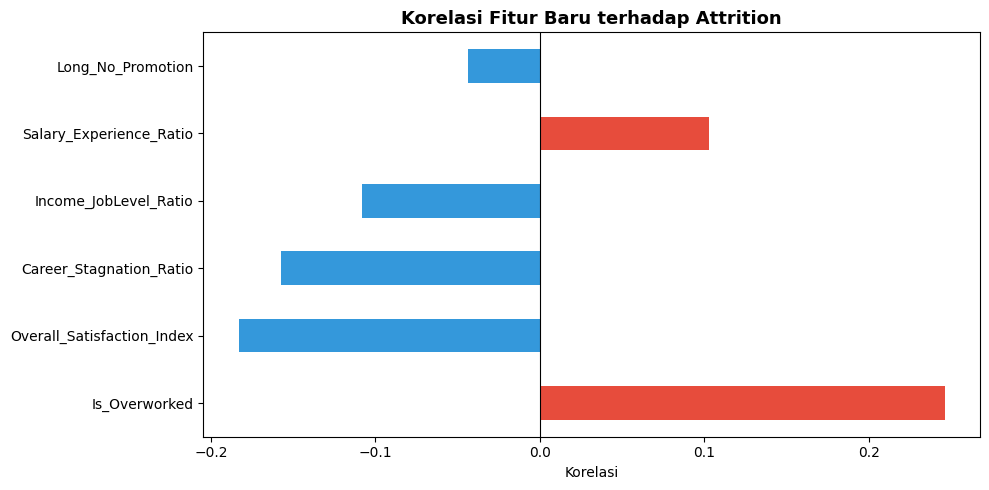

Nilai korelasi fitur baru:
Is_Overworked                 0.2461
Overall_Satisfaction_Index   -0.1831
Career_Stagnation_Ratio      -0.1575
Income_JobLevel_Ratio        -0.1083
Salary_Experience_Ratio       0.1026
Long_No_Promotion            -0.0437
Name: Attrition, dtype: float64


In [21]:
target_corr = df_fe[existing_new + ['Attrition']].corr()['Attrition'].drop('Attrition').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 5))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in target_corr.values]
target_corr.plot(kind='barh', color=colors)
plt.title('Korelasi Fitur Baru terhadap Attrition', fontsize=13, fontweight='bold')
plt.xlabel('Korelasi')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('Nilai korelasi fitur baru:')
print(target_corr.round(4))

### 5.4 Re-scaling Setelah Feature Engineering

In [22]:
X_final = df_fe.drop(columns=['Attrition'])
y_final = df_fe['Attrition']

bool_cols_fe = X_final.select_dtypes(include=['bool', 'uint8']).columns.tolist()
scale_cols_fe = X_final.select_dtypes(include=['int64', 'float64']).columns.tolist()
scale_cols_fe = [col for col in scale_cols_fe if col not in bool_cols_fe]

# Kecualikan kolom binary encoded
binary_encoded = ['Gender', 'OverTime', 'Is_Overworked', 'Long_No_Promotion']
scale_cols_fe = [col for col in scale_cols_fe if col not in binary_encoded]

scaler_final = StandardScaler()
X_final_scaled = X_final.copy()
X_final_scaled[scale_cols_fe] = scaler_final.fit_transform(X_final[scale_cols_fe])

print(f'✅ Final X shape (siap untuk modeling): {X_final_scaled.shape}')
print(f'✅ Final y shape: {y_final.shape}')
X_final_scaled.head()

✅ Final X shape (siap untuk modeling): (1470, 53)
✅ Final y shape: (1470,)


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,MaritalStatus_Single,Salary_Experience_Ratio,Career_Stagnation_Ratio,Overall_Satisfaction_Index,Long_No_Promotion,Is_Overworked,Income_JobLevel_Ratio,Age_Group_Millennial,Age_Group_Gen_X,Age_Group_Boomer
0,0.446350,0.742527,-1.010909,-0.891688,-0.660531,0,1.383138,0.379672,-0.057788,1.153254,...,True,0.288283,0.312425,-0.442844,0,1,0.069844,False,True,False
1,1.322365,-1.297775,-0.147150,-1.868426,0.254625,1,-0.240677,-1.026167,-0.057788,-0.660853,...,False,-0.420592,0.550630,0.053330,0,0,-0.511610,False,False,True
2,0.008343,1.414363,-0.887515,-0.891688,1.169781,1,1.284725,-1.026167,-0.961486,0.246200,...,True,-1.149322,-1.783771,0.053330,0,1,-1.151682,False,True,False
3,-0.429664,1.461466,-0.764121,1.061787,1.169781,0,-0.486709,0.379672,-0.961486,0.246200,...,False,-0.929146,1.069385,1.045679,0,1,-0.048064,True,False,False
4,-1.086676,-0.524295,-0.887515,-1.868426,-1.575686,1,-1.274014,0.379672,-0.961486,-0.660853,...,False,-0.317330,0.661791,-0.442844,0,0,0.705199,True,False,False


---
## 💾 6. Simpan Hasil Data Preparation

In [23]:
df_fe.to_csv('../data/employee_attrition_clean.csv', index=False)
X_final_scaled.to_csv('../data/X_preprocessed.csv', index=False)
y_final.to_csv('../data/y_target.csv', index=False)

print('✅ File tersimpan:')
print('  - ../data/employee_attrition_clean.csv  → dataset lengkap setelah cleaning + FE')
print('  - ../data/X_preprocessed.csv            → fitur siap modeling (sudah scaled)')
print('  - ../data/y_target.csv                  → label target')

✅ File tersimpan:
  - ../data/employee_attrition_clean.csv  → dataset lengkap setelah cleaning + FE
  - ../data/X_preprocessed.csv            → fitur siap modeling (sudah scaled)
  - ../data/y_target.csv                  → label target


---
## 📋 7. Ringkasan Data Preparation

In [25]:
print('=' * 55)
print('RINGKASAN DATA PREPARATION'.center(55))
print('=' * 55)

print(f'\n📌 DATASET AWAL')
print(f'   Dataset       : IBM HR Analytics Employee Attrition')
print(f'   Shape         : {df_original.shape}')

print(f'\n🧹 DATA CLEANING')
print(f'   Missing values: Ditangani (median/modus)')
print(f'   Duplikat      : Dihapus')
print(f'   Kolom dihapus : EmployeeNumber, EmployeeCount, Over18, StandardHours')
print(f'   Outlier       : Di-cap dengan IQR method')

print(f'\n⚙️  DATA PREPROCESSING')
print(f'   Target encode : Yes=1, No=0')
print(f'   Cat. encode   : Binary (Label) + One-Hot')
print(f'   Scaling       : StandardScaler (kecuali binary encoded)')

print(f'\n🔧 FEATURE ENGINEERING (7 fitur baru)')
print(f'   1. Salary_Experience_Ratio')
print(f'   2. Career_Stagnation_Ratio')
print(f'   3. Overall_Satisfaction_Index')
print(f'   4. Long_No_Promotion (flag)')
print(f'   5. Is_Overworked (flag)')
print(f'   6. Income_JobLevel_Ratio')
print(f'   7. Age_Group (binning → dummy)')

print(f'\n📊 DATASET FINAL')
print(f'   Shape X       : {X_final_scaled.shape}')
print(f'   Shape y       : {y_final.shape}')
print(f'   Attrition=1   : {y_final.sum()} ({y_final.mean()*100:.1f}%)')
print(f'   Attrition=0   : {(y_final==0).sum()} ({(y_final==0).mean()*100:.1f}%)')
print('=' * 55)

               RINGKASAN DATA PREPARATION              

📌 DATASET AWAL
   Dataset       : IBM HR Analytics Employee Attrition
   Shape         : (1470, 35)

🧹 DATA CLEANING
   Missing values: Ditangani (median/modus)
   Duplikat      : Dihapus
   Kolom dihapus : EmployeeNumber, EmployeeCount, Over18, StandardHours
   Outlier       : Di-cap dengan IQR method

⚙️  DATA PREPROCESSING
   Target encode : Yes=1, No=0
   Cat. encode   : Binary (Label) + One-Hot
   Scaling       : StandardScaler (kecuali binary encoded)

🔧 FEATURE ENGINEERING (7 fitur baru)
   1. Salary_Experience_Ratio
   2. Career_Stagnation_Ratio
   3. Overall_Satisfaction_Index
   4. Long_No_Promotion (flag)
   5. Is_Overworked (flag)
   6. Income_JobLevel_Ratio
   7. Age_Group (binning → dummy)

📊 DATASET FINAL
   Shape X       : (1470, 53)
   Shape y       : (1470,)
   Attrition=1   : 237 (16.1%)
   Attrition=0   : 1233 (83.9%)
